# PS4 — Rate Coding Baseline Comparison
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — February 2026

**Purpose:** Establish whether DFC orbit coding (12 symbols) genuinely exceeds simple rate coding (vary I_bias, K=0). Answers the reviewer question: *does DFC add capacity beyond rate coding?*

**Phases:** A — I_bias sweep | B — template building | C — capacity test | D — comparison + Gate PS-G4

**Gate PS-G4:** HH-DFC N* > HH-Rate N*

**Numba:** NO `cache=True`, NO `np.clip` — uses `clamp01()`

## CELL 1 — Setup

In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import json, os, time
from datetime import datetime

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/My Drive/HHSMC/full_study'
    PS1_DIR    = BASE + '/PS1_write_protocol'
    PS2_DIR    = BASE + '/PS2_read_protocol'
    OUTPUT_DIR = BASE + '/PS4_rate_baseline'
except ImportError:
    PS1_DIR    = './PS1_results'
    PS2_DIR    = './PS2_results'
    OUTPUT_DIR = './PS4_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('PS4 output:', OUTPUT_DIR)
print('Timestamp: ', datetime.now().isoformat())
print('Phase PS4 -- Rate Coding Baseline Comparison')

Mounted at /content/drive
PS4 output: /content/drive/My Drive/HHSMC/full_study/PS4_rate_baseline
Timestamp:  2026-03-06T18:07:54.520494
Phase PS4 -- Rate Coding Baseline Comparison


## CELL 2 — HH Model (V-shifted, rest=0) — NO cache=True, NO np.clip

In [2]:
C_M=1.0; G_NA=120.0; G_K=36.0; G_L=0.3
E_NA=115.0; E_K=-12.0; E_L=10.6; DT=0.01

@njit
def alpha_m(V):
    x = 25.0 - V
    if abs(x) < 1e-7: return 1.0
    return 0.1 * x / (np.exp(x/10.0) - 1.0)

@njit
def beta_m(V): return 4.0 * np.exp(-V/18.0)

@njit
def alpha_h(V): return 0.07 * np.exp(-V/20.0)

@njit
def beta_h(V): return 1.0 / (np.exp((30.0-V)/10.0) + 1.0)

@njit
def alpha_n(V):
    x = 10.0 - V
    if abs(x) < 1e-7: return 0.1
    return 0.01 * x / (np.exp(x/10.0) - 1.0)

@njit
def beta_n(V): return 0.125 * np.exp(-V/80.0)

@njit
def clamp01(x):
    if x < 0.0: return 0.0
    if x > 1.0: return 1.0
    return x

@njit
def hh_rhs(V, m, h, n, I):
    dV = (I - G_NA*m*m*m*h*(V-E_NA) - G_K*n*n*n*n*(V-E_K) - G_L*(V-E_L)) / C_M
    dm = alpha_m(V)*(1.0-m) - beta_m(V)*m
    dh = alpha_h(V)*(1.0-h) - beta_h(V)*h
    dn = alpha_n(V)*(1.0-n) - beta_n(V)*n
    return dV, dm, dh, dn

@njit
def hh_ss(V):
    am=alpha_m(V); bm=beta_m(V)
    ah=alpha_h(V); bh=beta_h(V)
    an=alpha_n(V); bn=beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

print('HH model defined.')

HH model defined.


## CELL 3 — Simulation Engine (K=0, rate coding)

Identical to `simulate_clean` in PS2/PS3 but K=0 at all times.

In [3]:
@njit
def simulate_rate(I_bias, T_ms, dt=0.01):
    n_steps = int(T_ms / dt)
    V = 0.0
    m, h, n = hh_ss(V)
    max_spk = int(T_ms/2) + 100
    spk = np.empty(max_spk)
    ns = 0
    Vp = V
    for s in range(n_steps):
        dV1,dm1,dh1,dn1 = hh_rhs(V,m,h,n,I_bias)
        Vk2=V+.5*dt*dV1; mk2=m+.5*dt*dm1; hk2=h+.5*dt*dh1; nk2=n+.5*dt*dn1
        dV2,dm2,dh2,dn2 = hh_rhs(Vk2,mk2,hk2,nk2,I_bias)
        Vk3=V+.5*dt*dV2; mk3=m+.5*dt*dm2; hk3=h+.5*dt*dh2; nk3=n+.5*dt*dn2
        dV3,dm3,dh3,dn3 = hh_rhs(Vk3,mk3,hk3,nk3,I_bias)
        Vk4=V+dt*dV3; mk4=m+dt*dm3; hk4=h+dt*dh3; nk4=n+dt*dn3
        dV4,dm4,dh4,dn4 = hh_rhs(Vk4,mk4,hk4,nk4,I_bias)
        Vn = V + (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m = clamp01(m + (dt/6.0)*(dm1+2*dm2+2*dm3+dm4))
        h = clamp01(h + (dt/6.0)*(dh1+2*dh2+2*dh3+dh4))
        n = clamp01(n + (dt/6.0)*(dn1+2*dn2+2*dn3+dn4))
        if Vp <= 0.0 and Vn > 0.0 and ns < max_spk:
            spk[ns] = s * dt
            ns += 1
        Vp = Vn; V = Vn
    return spk[:ns]

print('simulate_rate defined.')

simulate_rate defined.


## CELL 4 — Classifier (identical to PS2/PS3)

The same POLD classifier reused verbatim. Fair comparison requires the same decoder.

In [4]:
def classify_orbit_from_isis(isis, templates):
    # Identical to PS2/PS3 classifier - do not modify.
    if len(isis) < 1:
        return -1, 0.0, {}
    obs_mean = np.mean(isis)
    scores = {}
    for tmpl in templates:
        tidx   = tmpl['lib_idx']
        d_mean = abs(obs_mean - tmpl['isi_mean'])
        sigma  = max(tmpl['isi_std'], 0.5)
        s_mean = np.exp(-0.5 * (d_mean/sigma)**2)
        pat = tmpl['pattern_template']
        pl  = len(pat)
        if pl > 1 and len(isis) >= pl:
            best_ps = 0.0
            for offset in range(min(pl, len(isis)-pl+1)):
                seg = isis[offset:offset+pl]
                if len(seg) < pl: break
                pa = np.array(pat)
                pm = np.mean(pa); sm = np.mean(seg)
                num = np.sum((seg-sm)*(pa-pm))
                den = np.sqrt(np.sum((seg-sm)**2)) * np.sqrt(np.sum((pa-pm)**2))
                corr = num/den if den > 1e-10 else 0.0
                rel_err = np.mean(np.abs(seg-pa)/(pa+0.1))
                cps = 0.5*max(corr,0.0) + 0.5*np.exp(-2.0*rel_err)
                if cps > best_ps: best_ps = cps
            s_pat = best_ps
        else:
            s_pat = s_mean
        scores[tidx] = 0.6*s_mean + 0.4*s_pat
    best_idx = max(scores, key=scores.get)
    sv = sorted(scores.values(), reverse=True)
    conf = min((sv[0]-sv[1])/(sv[1]+1e-10), 1.0) if len(sv)>=2 and sv[1]>0 else 1.0
    return best_idx, conf, scores

print('Classifier defined.')

Classifier defined.


## CELL 5 — Phase A: I_bias Sweep (K=0)

In [5]:
def run_phase_A(I_range=None, T_ms=3000.0, T_trans=500.0, dt=0.01):
    if I_range is None:
        I_range = np.arange(6.0, 100.1, 0.5)
    print('\nPhase A: I_bias sweep (K=0)')
    print('  JIT warmup...', end=' ', flush=True)
    _ = simulate_rate(10.0, 300.0, dt)
    print('done.')
    results = []
    t0 = time.time()
    for i, Ib in enumerate(I_range):
        spk      = simulate_rate(Ib, T_ms, dt)
        post     = spk[spk >= T_trans]
        if len(post) < 5:
            results.append({'I_bias':float(Ib), 'class':'silent',
                            'isi_mean':0.0,'isi_std':0.0,
                            'isi_cv':-1.0,'firing_rate_hz':0.0,'n_spikes':0})
            continue
        isis    = np.diff(post)
        mu      = float(np.mean(isis))
        sd      = float(np.std(isis))
        cv      = float(sd/mu) if mu > 0 else -1.0
        rate_hz = len(post) / ((T_ms - T_trans) / 1000.0)
        cls     = 'tonic' if cv < 0.02 else ('quasi_periodic' if cv < 0.10 else 'irregular')
        results.append({'I_bias':float(Ib),'class':cls,'isi_mean':mu,
                        'isi_std':sd,'isi_cv':cv,'firing_rate_hz':float(rate_hz),
                        'n_spikes':len(post)})
        if (i+1) % 20 == 0 or i == len(I_range)-1:
            print(f'  [{i+1:3d}/{len(I_range)}] I={Ib:.1f}  {cls:12s}  '
                  f'ISI={mu:6.1f}ms  CV={cv:.3f}  ({time.time()-t0:.0f}s)')
    print(f'  Phase A complete in {time.time()-t0:.1f}s')
    n_tonic = sum(1 for r in results if r['class']=='tonic')
    print(f'  Tonic states: {n_tonic}/{len(results)}')
    return results

print('Phase A function defined.')

Phase A function defined.


## CELL 6 — Phase B: Select Distinguishable States + Build Templates

Uses the same 2ms ISI separability threshold as PS0.

In [6]:
def select_distinguishable_states(sweep, min_sep_ms=2.0):
    tonic = sorted([r for r in sweep if r['class']=='tonic' and r['isi_mean']>0],
                   key=lambda r: r['isi_mean'])
    print(f'\nPhase B: selecting from {len(tonic)} tonic states (sep>={min_sep_ms}ms)')
    sel = []
    for r in tonic:
        if not sel or min(abs(r['isi_mean']-s['isi_mean']) for s in sel) >= min_sep_ms:
            sel.append(r)
    print(f'  Selected: {len(sel)} states')
    print(f'  ISI range: {sel[0]["isi_mean"]:.1f} to {sel[-1]["isi_mean"]:.1f} ms')
    for i, s in enumerate(sel):
        print(f'  [{i+1:2d}] I_bias={s["I_bias"]:.2f}  '
              f'ISI={s["isi_mean"]:6.1f}ms  {s["firing_rate_hz"]:.1f}Hz')
    return sel


def build_rate_templates(sel, T_sim=5000.0, T_trans=1000.0, n_runs=5, dt=0.01):
    print(f'\nBuilding templates for {len(sel)} rate states ({n_runs} runs each)')
    tmpls = []
    for i, st in enumerate(sel):
        all_isis = []
        for _ in range(n_runs):
            spk  = simulate_rate(st['I_bias'], T_sim, dt)
            post = spk[spk >= T_trans]
            if len(post) >= 3:
                all_isis.extend(np.diff(post).tolist())
        if len(all_isis) < 10:
            print(f'  [{i}] I={st["I_bias"]:.2f}: too few spikes, skipping')
            continue
        arr = np.array(all_isis)
        t = {'lib_idx':i, 'type_id':f'rate_{i}', 'category':'tonic',
             'K':0.0, 'tau_ms':0.0, 'I_bias':float(st['I_bias']),
             'pattern_length':1, 'pattern_template':[float(np.mean(arr))],
             'isi_mean':float(np.mean(arr)), 'isi_std':float(np.std(arr)),
             'isi_cv':float(np.std(arr)/np.mean(arr)), 'n_samples':len(arr)}
        tmpls.append(t)
        print(f'  [{i+1:2d}] I={st["I_bias"]:.2f}  '
              f'ISI={t["isi_mean"]:.1f}+/-{t["isi_std"]:.2f}ms')
    return tmpls

print('Phase B functions defined.')

Phase B functions defined.


## CELL 7 — Phase C: Capacity Test for Rate Coding

Identical protocol to PS3 Phase C: k = 2..N_max, 20 trials, 10 ISIs, >=90% threshold.

In [7]:
def run_rate_capacity(sel, tmpls, n_trials=20, T_sim=3000.0,
                      T_trans=500.0, n_isis=10, dt=0.01):
    N = len(sel)
    print(f'\nPhase C: capacity test (up to {N} states, {n_trials} trials, {n_isis} ISIs)')
    results = []
    t0 = time.time()
    for k in range(2, N+1):
        idx   = list(dict.fromkeys(
                    np.round(np.linspace(0, N-1, k)).astype(int).tolist()))
        k_sel = [sel[j]   for j in idx]
        k_t   = [dict(tmpls[j]) for j in idx]
        for ti in range(len(k_t)): k_t[ti]['lib_idx'] = ti
        correct = total = 0
        for si, st in enumerate(k_sel):
            for _ in range(n_trials):
                spk  = simulate_rate(st['I_bias'], T_sim, dt)
                post = spk[spk >= T_trans]
                if len(post) < n_isis + 2: continue
                isis = np.diff(post)
                if len(isis) < n_isis: continue
                start = np.random.randint(0, max(1, len(isis)-n_isis))
                obs   = isis[start:start+n_isis]
                pred, _, _ = classify_orbit_from_isis(obs, k_t)
                if pred == si: correct += 1
                total += 1
        acc = correct/total if total > 0 else 0.0
        status = 'OK' if acc >= 0.90 else '--'
        print(f'    k={k:2d}: {acc:.1%} ({correct}/{total}) {status}')
        results.append({'k':k,'accuracy':acc,'n_correct':correct,'n_total':total})
    N_star = max((r['k'] for r in results if r['accuracy'] >= 0.90), default=0)
    print(f'  Phase C complete in {time.time()-t0:.1f}s')
    print(f'  N*_rate = {N_star}')
    return {'capacity_results':results, 'N_star_rate':N_star}

print('Phase C function defined.')

Phase C function defined.


## CELL 8 — Phase D: Comparison + Gate PS-G4

In [8]:
def run_comparison_and_gate(N_dfc, N_rate, sel, dfc_tmpls, rate_tmpls):
    print('\n' + '='*70)
    print('PHASE D + GATE PS-G4 -- HH-DFC vs HH-Rate')
    print('='*70)
    print(f'  N*_DFC   = {N_dfc}  (from PS3 Gate PS-G3)')
    print(f'  N*_Rate  = {N_rate}')
    if dfc_tmpls:
        dfc_min = min(t['isi_mean'] for t in dfc_tmpls)
        dfc_max = max(t['isi_mean'] for t in dfc_tmpls)
        print(f'  DFC ISI range:  {dfc_min:.1f} to {dfc_max:.1f} ms')
    if sel:
        print(f'  Rate ISI range: {sel[0]["isi_mean"]:.1f} to {sel[-1]["isi_mean"]:.1f} ms')
    print(f'  DFC orbit types: 12 categories (tonic, doublet, triplet, bursts)')
    print(f'  Rate orbit types: tonic only')
    delta    = N_dfc - N_rate
    dfc_wins = delta > 0
    print(f'\n  DFC advantage: {delta:+d} symbols')
    if dfc_wins:
        print(f'  HH-DFC EXCEEDS rate coding by {delta} symbol(s)')
        print('  Paper claim C1 supported: DFC adds measurable capacity.')
    elif delta == 0:
        print('  HH-DFC MATCHES rate coding capacity')
        print('  Reframe contribution: topological diversity, not raw capacity.')
    else:
        print('  Rate coding exceeds DFC (unexpected) -- investigate separability criterion.')
    print('\n  Qualitative note:')
    print('  DFC orbits include burst patterns, doublets, triplets inaccessible')
    print('  via any I_bias value. This topological argument holds regardless of N*.')
    print('\n' + '='*70)
    print('GATE PS-G4 -- DFC ADDS CAPACITY BEYOND RATE CODING')
    print('='*70)
    label = 'PASS' if dfc_wins else 'FAIL'
    print(f'  G4: HH-DFC N* > HH-Rate N* --> {label}')
    print('='*70)
    return {'N_star_dfc':N_dfc, 'N_star_rate':N_rate,
            'delta':delta, 'dfc_wins':dfc_wins, 'gate':'PS-G4', 'pass':dfc_wins}

print('Comparison and gate function defined.')

Comparison and gate function defined.


## CELL 9 — Visualization

In [9]:
def plot_sweep(sweep, save_dir=None):
    tonic = [r for r in sweep if r['class']=='tonic']
    other = [r for r in sweep if r['class'] not in ('tonic','silent') and r['isi_mean']>0]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax = axes[0]
    if tonic:
        ax.plot([r['I_bias'] for r in tonic],[r['isi_mean'] for r in tonic],
                'o',color='steelblue',markersize=4,label='Tonic (CV<0.02)')
    if other:
        ax.plot([r['I_bias'] for r in other],[r['isi_mean'] for r in other],
                's',color='gray',markersize=3,alpha=0.5,label='Other')
    ax.set_xlabel('I_bias (uA/cm2)'); ax.set_ylabel('Mean ISI (ms)')
    ax.set_title('Rate Coding: ISI vs I_bias (K=0)'); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1]
    valid = [r for r in sweep if r['isi_cv']>0]
    ax.plot([r['I_bias'] for r in valid],[r['isi_cv'] for r in valid],
            'o',color='coral',markersize=4)
    ax.axhline(0.02,color='navy',linestyle='--',linewidth=1.5,label='CV=0.02 threshold')
    ax.set_xlabel('I_bias (uA/cm2)'); ax.set_ylabel('ISI CV')
    ax.set_title('Variability vs I_bias'); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[2]
    ax.plot([r['I_bias'] for r in tonic],[r['firing_rate_hz'] for r in tonic],
            'o',color='seagreen',markersize=4)
    ax.set_xlabel('I_bias (uA/cm2)'); ax.set_ylabel('Firing Rate (Hz)')
    ax.set_title('Rate vs I_bias (Tonic Only)'); ax.grid(alpha=0.3)
    plt.suptitle('Phase A: HH Rate Coding Landscape (K=0)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        fig.savefig(os.path.join(save_dir,'PS4_phase_A_sweep.png'),dpi=300,bbox_inches='tight')
    plt.show()


def plot_comparison(comp, rate_cap, save_dir=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    res = rate_cap['capacity_results']
    rk  = [r['k'] for r in res]
    ra  = [r['accuracy']*100 for r in res]
    ax  = axes[0]
    ax.plot(rk, ra,'s--',color='coral',linewidth=2,markersize=8,
            label='HH-Rate (N*=' + str(comp['N_star_rate']) + ')')
    ax.axhline(90,color='black',linestyle=':',linewidth=1.5,label='90% threshold')
    ax.set_xlabel('Number of Symbols (k)'); ax.set_ylabel('Accuracy (%)')
    ax.set_title('HH-Rate Capacity'); ax.legend(); ax.set_ylim(0,105); ax.grid(alpha=0.3)
    ax = axes[1]
    labels = ['HH-DFC\n(K,tau switch)','HH-Rate\n(I_bias only)']
    vals   = [comp['N_star_dfc'], comp['N_star_rate']]
    bars   = ax.bar(labels, vals, color=['steelblue','coral'], width=0.5, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(int(bar.get_height())), ha='center', va='bottom',
                fontsize=14, fontweight='bold')
    d = comp['delta']
    ax.set_ylabel('N* (symbols at >=90% accuracy)')
    ax.set_title('Capacity Comparison')
    ax.set_xlabel('DFC advantage: ' + ('+' if d>=0 else '') + str(d) + ' symbols',
                  color='steelblue' if d>=0 else 'red')
    ax.set_ylim(0, max(vals)+3); ax.grid(alpha=0.3, axis='y')
    plt.suptitle('PS4: HH-DFC vs HH-Rate Baseline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        fig.savefig(os.path.join(save_dir,'PS4_comparison.png'),dpi=300,bbox_inches='tight')
    plt.show()

print('Visualization functions defined.')

Visualization functions defined.


## CELL 10 — Load DFC Results from PS1/PS2

In [10]:
def load_dfc_results(ps1_dir, ps2_dir):
    lib_path = os.path.join(ps1_dir, 'PS1_library.json')
    if not os.path.exists(lib_path):
        lib_path = os.path.join(ps1_dir, 'PS1_locked_library.json')
    with open(lib_path) as f:
        data = json.load(f)
    library    = data.get('library', data.get('locked_library', data))
    locked_idx = data.get('locked_idx', [o['lib_idx'] for o in library])
    locked_lib = [o for o in library if o['lib_idx'] in locked_idx]
    print(f'  Loaded {len(library)} library orbits, {len(locked_lib)} locked')
    tmpl_path = os.path.join(ps2_dir, 'PS2_templates.json')
    with open(tmpl_path) as f:
        tmpl_data = json.load(f)
    templates = tmpl_data.get('templates', tmpl_data)
    print(f'  Loaded {len(templates)} templates')
    return locked_lib, templates

print('DFC loader defined.')

DFC loader defined.


## CELL 10b — Orbit Visualization for Rate-Coding States

For each of the 6 selected rate-coding states: plot the voltage trace and the ISI series. The flat ISI series (CV=0.000) confirms each is a true stable limit cycle, not a transient pattern.

In [11]:
def plot_rate_orbits(sel, T_ms=500.0, T_trans=200.0, dt=0.01, save_dir=None):
    # Plot voltage trace and ISI pattern for each selected rate-coding state.
    # T_ms: total simulation time; T_trans: transient to discard before plotting.
    n = len(sel)
    fig, axes = plt.subplots(n, 2, figsize=(16, 2.8*n))
    if n == 1: axes = [axes]
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, n))

    orbit_data = []
    for i, st in enumerate(sel):
        Ib = st['I_bias']
        # Simulate long enough to fill trace + measure ISIs
        spk = simulate_rate(Ib, T_trans + T_ms, dt)
        post = spk[spk >= T_trans]
        isis = np.diff(post) if len(post) >= 2 else np.array([])
        mu  = float(np.mean(isis)) if len(isis) > 0 else 0.0
        hz  = float(1000.0 / mu)  if mu > 0 else 0.0

        # Voltage trace: run again and record V
        n_steps = int((T_trans + T_ms) / dt)
        V = 0.0
        m_g, h_g, n_g = float(alpha_m(V)/(alpha_m(V)+beta_m(V))), \
                         float(alpha_h(V)/(alpha_h(V)+beta_h(V))), \
                         float(alpha_n(V)/(alpha_n(V)+beta_n(V)))
        t_arr, V_arr = [], []
        for s in range(n_steps):
            t_now = s * dt
            dV1,dm1,dh1,dn1 = hh_rhs(V,m_g,h_g,n_g,Ib)
            Vk2=V+.5*dt*dV1; mk2=m_g+.5*dt*dm1; hk2=h_g+.5*dt*dh1; nk2=n_g+.5*dt*dn1
            dV2,dm2,dh2,dn2 = hh_rhs(Vk2,mk2,hk2,nk2,Ib)
            Vk3=V+.5*dt*dV2; mk3=m_g+.5*dt*dm2; hk3=h_g+.5*dt*dh2; nk3=n_g+.5*dt*dn2
            dV3,dm3,dh3,dn3 = hh_rhs(Vk3,mk3,hk3,nk3,Ib)
            Vk4=V+dt*dV3; mk4=m_g+dt*dm3; hk4=h_g+dt*dh3; nk4=n_g+dt*dn3
            dV4,dm4,dh4,dn4 = hh_rhs(Vk4,mk4,hk4,nk4,Ib)
            Vn = V + (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
            m_g = clamp01(m_g+(dt/6.0)*(dm1+2*dm2+2*dm3+dm4))
            h_g = clamp01(h_g+(dt/6.0)*(dh1+2*dh2+2*dh3+dh4))
            n_g = clamp01(n_g+(dt/6.0)*(dn1+2*dn2+2*dn3+dn4))
            if t_now >= T_trans:
                t_arr.append(t_now - T_trans)
                V_arr.append(Vn)
            V = Vn
        t_arr = np.array(t_arr)
        V_arr = np.array(V_arr)

        # Plot voltage trace
        ax = axes[i][0]
        ax.plot(t_arr, V_arr, color=colors[i], linewidth=1.2)
        ax.set_xlim(0, T_ms)
        ax.set_ylim(-20, 130)
        ax.set_ylabel('V (mV)', fontsize=10)
        ax.set_title(
            f'State {i+1}  |  I_bias={Ib:.1f} uA/cm2  |  '
            f'ISI={mu:.2f} ms  |  Rate={hz:.1f} Hz',
            fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.25)
        if i == n-1: ax.set_xlabel('Time (ms)', fontsize=10)

        # Plot ISI series (shows orbit is truly repeating)
        ax2 = axes[i][1]
        if len(isis) > 0:
            ax2.plot(range(len(isis)), isis, 'o-',
                     color=colors[i], markersize=4, linewidth=1.2)
            ax2.axhline(mu, color='black', linestyle='--',
                        linewidth=1.2, label=f'Mean ISI={mu:.2f}ms')
            ax2.set_ylim(max(0, mu-5), mu+5)
            ax2.set_ylabel('ISI (ms)', fontsize=10)
            ax2.set_title(
                f'ISI Series — CV={st["isi_cv"]:.4f}  '
                f'(perfectly stable limit cycle)',
                fontsize=10)
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.25)
            if i == n-1: ax2.set_xlabel('Spike index', fontsize=10)

        orbit_data.append({'state_idx': i+1, 'I_bias': float(Ib),
                           'isi_mean_ms': mu, 'firing_rate_hz': hz,
                           'isi_cv': st['isi_cv'], 'n_isis': len(isis)})

    plt.suptitle(
        'PS4: Rate-Coding Orbits (K=0) — All 6 Stable Limit Cycles',
        fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'PS4_rate_orbits.png')
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f'  Saved: {path}')
    plt.show()
    return orbit_data

print('plot_rate_orbits defined.')

plot_rate_orbits defined.


## CELL 11 — MAIN EXECUTION

PS4 -- RATE CODING BASELINE COMPARISON
Option C: HH Delay-Directed Orbit Selection

Loading DFC reference (PS1 + PS2)...
  DFC N* = 12

PHASE A -- I_bias Sweep

Phase A: I_bias sweep (K=0)
  JIT warmup... done.
  [ 20/189] I=15.5  tonic         ISI=  12.6ms  CV=0.000  (2s)
  [ 40/189] I=25.5  tonic         ISI=  10.7ms  CV=0.000  (4s)
  [ 60/189] I=35.5  tonic         ISI=   9.6ms  CV=0.000  (6s)
  [ 80/189] I=45.5  tonic         ISI=   8.8ms  CV=0.000  (7s)
  [100/189] I=55.5  tonic         ISI=   8.2ms  CV=0.000  (9s)
  [120/189] I=65.5  tonic         ISI=   7.8ms  CV=0.000  (12s)
  [140/189] I=75.5  tonic         ISI=   7.4ms  CV=0.000  (15s)
  Phase A complete in 19.6s
  Tonic states: 141/189


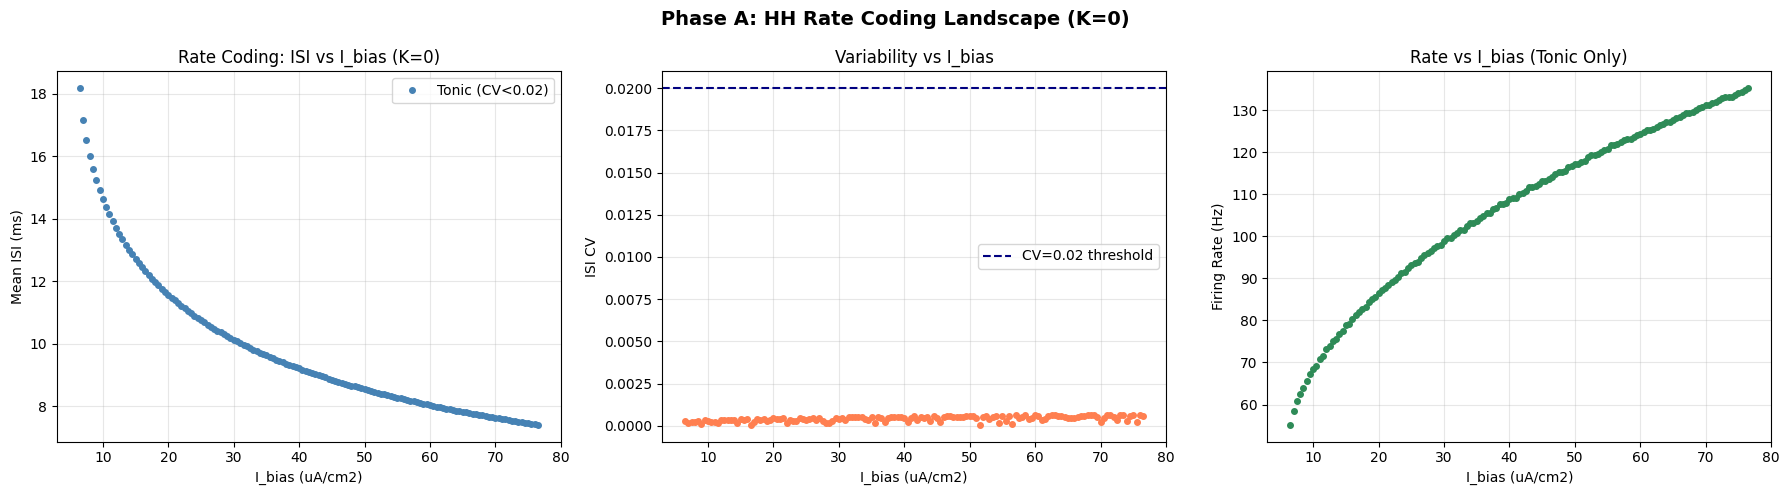


PHASE B -- State Selection

Phase B: selecting from 141 tonic states (sep>=2.0ms)
  Selected: 6 states
  ISI range: 7.4 to 18.2 ms
  [ 1] I_bias=76.50  ISI=   7.4ms  135.2Hz
  [ 2] I_bias=37.50  ISI=   9.4ms  106.4Hz
  [ 3] I_bias=20.50  ISI=  11.5ms  87.2Hz
  [ 4] I_bias=12.50  ISI=  13.5ms  74.0Hz
  [ 5] I_bias=8.50  ISI=  15.6ms  64.0Hz
  [ 6] I_bias=6.50  ISI=  18.2ms  55.2Hz

Building templates for 6 rate states (5 runs each)
  [ 1] I=76.50  ISI=7.4+/-0.00ms
  [ 2] I=37.50  ISI=9.4+/-0.00ms
  [ 3] I=20.50  ISI=11.5+/-0.00ms
  [ 4] I=12.50  ISI=13.5+/-0.00ms
  [ 5] I=8.50  ISI=15.6+/-0.00ms
  [ 6] I=6.50  ISI=18.2+/-0.00ms

ORBIT VISUALIZATION
  Saved: /content/drive/My Drive/HHSMC/full_study/PS4_rate_baseline/PS4_rate_orbits.png


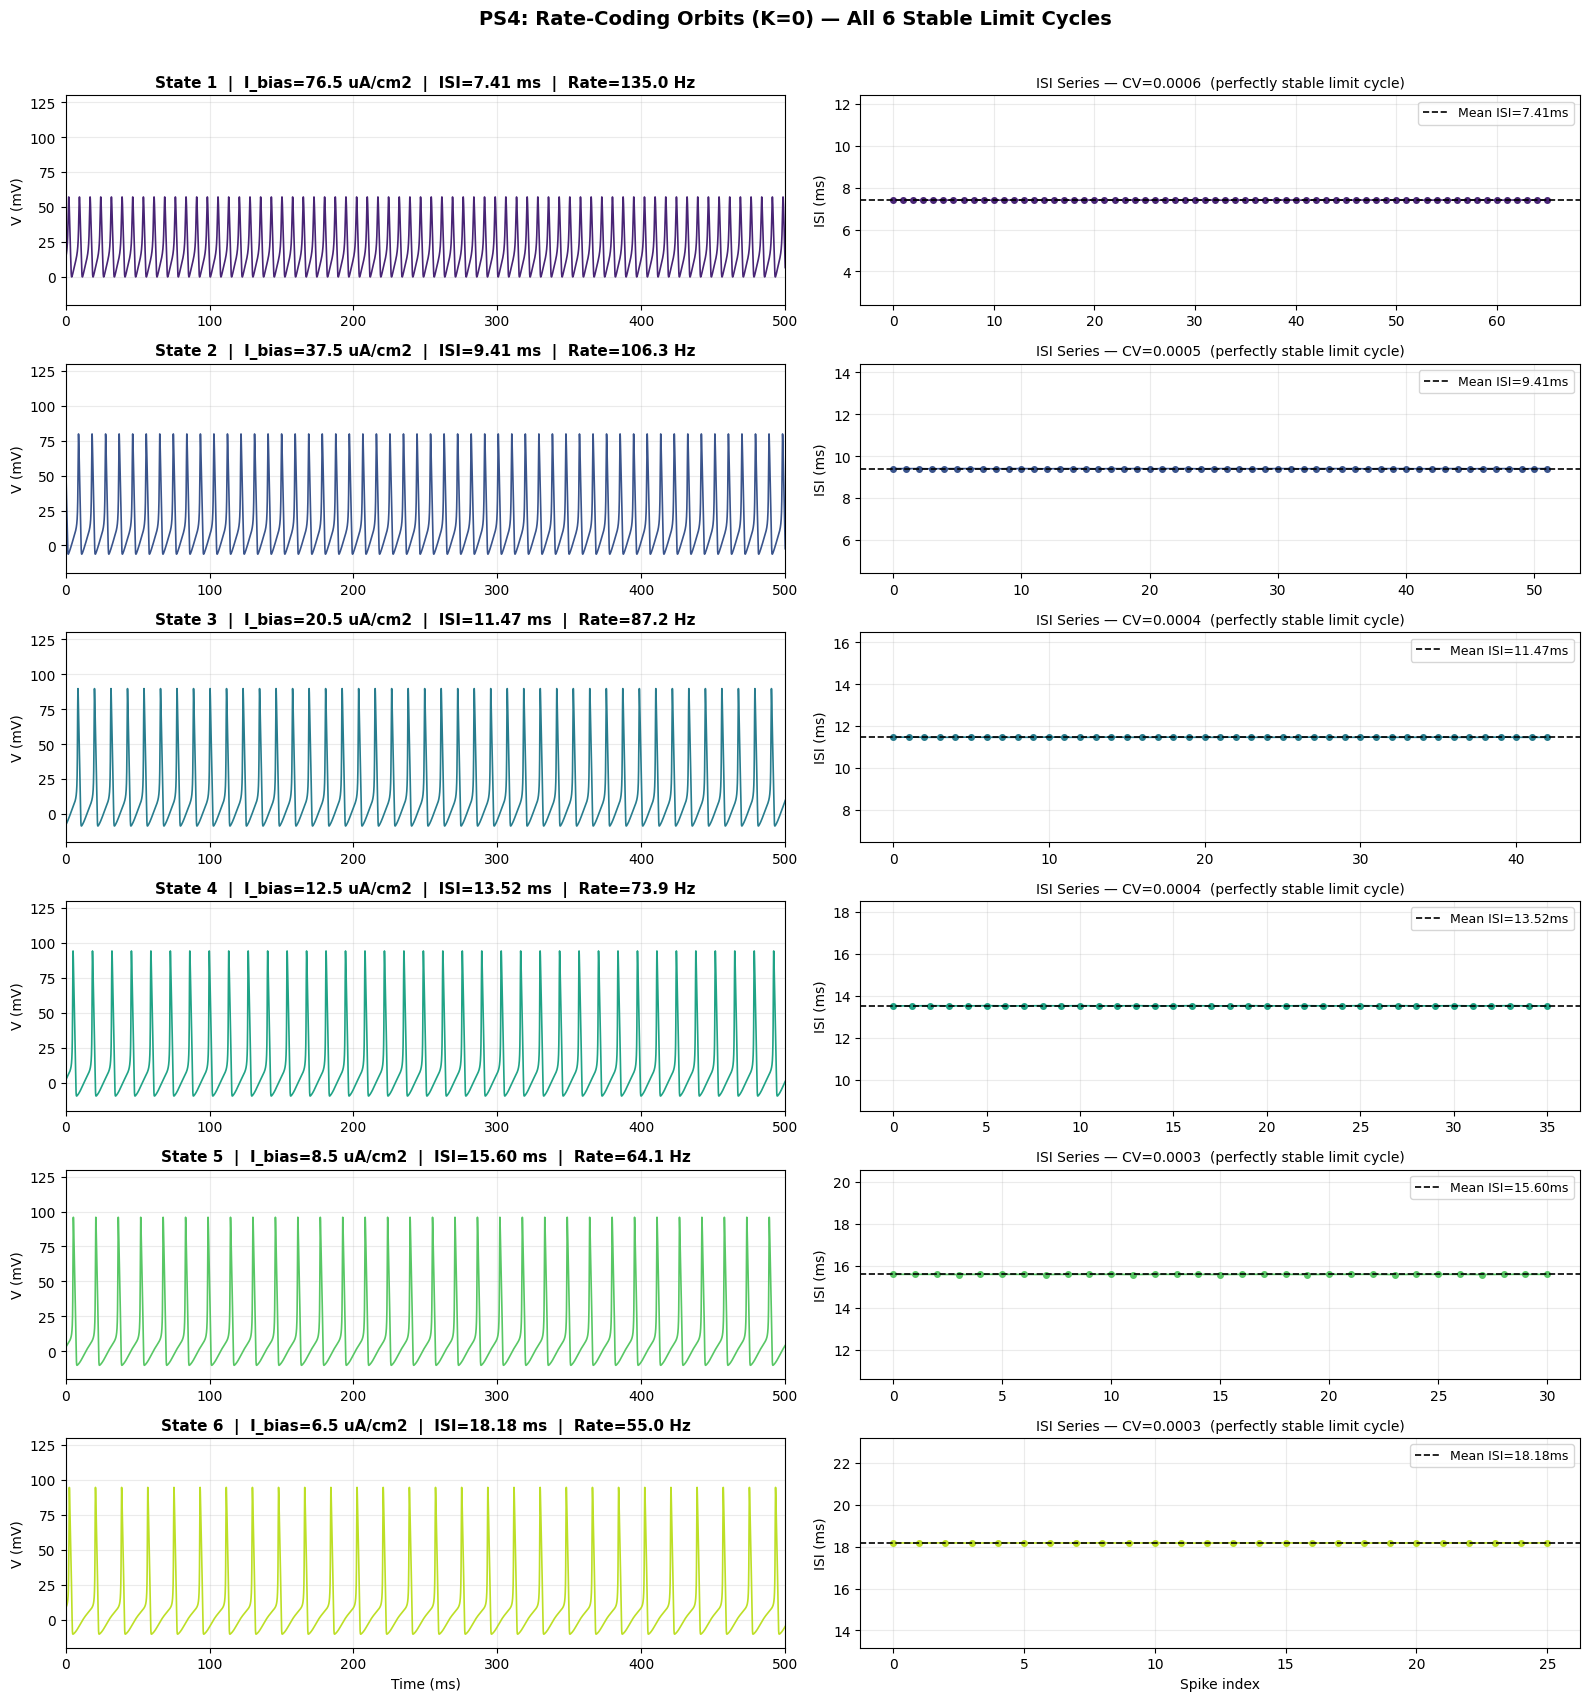


PHASE C -- Capacity Test

Phase C: capacity test (up to 6 states, 20 trials, 10 ISIs)
    k= 2: 100.0% (40/40) OK
    k= 3: 100.0% (60/60) OK
    k= 4: 100.0% (80/80) OK
    k= 5: 100.0% (100/100) OK
    k= 6: 100.0% (120/120) OK
  Phase C complete in 41.9s
  N*_rate = 6

PHASE D + GATE PS-G4 -- HH-DFC vs HH-Rate
  N*_DFC   = 12  (from PS3 Gate PS-G3)
  N*_Rate  = 6
  Rate ISI range: 7.4 to 18.2 ms
  DFC orbit types: 12 categories (tonic, doublet, triplet, bursts)
  Rate orbit types: tonic only

  DFC advantage: +6 symbols
  HH-DFC EXCEEDS rate coding by 6 symbol(s)
  Paper claim C1 supported: DFC adds measurable capacity.

  Qualitative note:
  DFC orbits include burst patterns, doublets, triplets inaccessible
  via any I_bias value. This topological argument holds regardless of N*.

GATE PS-G4 -- DFC ADDS CAPACITY BEYOND RATE CODING
  G4: HH-DFC N* > HH-Rate N* --> PASS


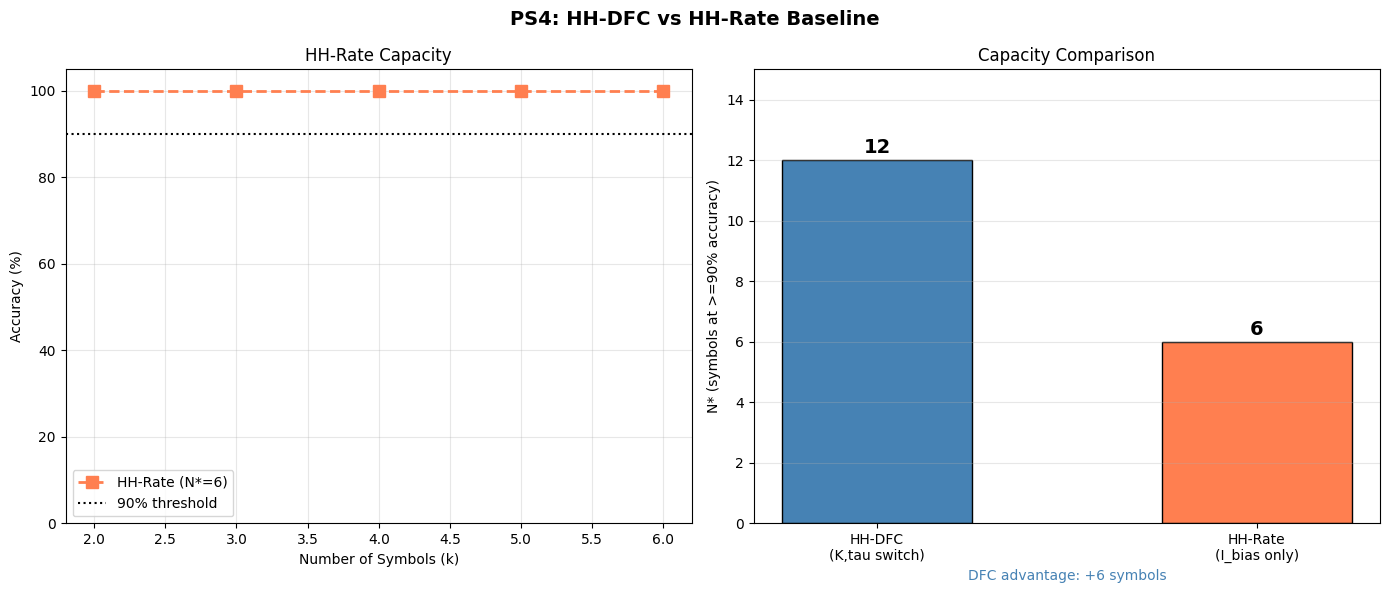


Saved: /content/drive/My Drive/HHSMC/full_study/PS4_rate_baseline/PS4_rate_baseline.json

PS4 COMPLETE
  Rate states found: 6
  N*_rate:           6
  N*_DFC:            12
  Gate PS-G4:        PASS


In [12]:
if __name__ == '__main__' or True:

    print('='*70)
    print('PS4 -- RATE CODING BASELINE COMPARISON')
    print('Option C: HH Delay-Directed Orbit Selection')
    print('='*70)

    # Load DFC reference
    print('\nLoading DFC reference (PS1 + PS2)...')
    try:
        dfc_lib, dfc_tmpls = load_dfc_results(PS1_DIR, PS2_DIR)
        N_STAR_DFC = 12  # from PS3 Gate PS-G3
    except Exception as e:
        print(f'  Warning: {e}  -- using N*_dfc=12 fallback')
        dfc_lib, dfc_tmpls = [], []
        N_STAR_DFC = 12
    print(f'  DFC N* = {N_STAR_DFC}')

    # Phase A
    print('\n' + '='*50 + '\nPHASE A -- I_bias Sweep\n' + '='*50)
    sweep = run_phase_A(np.arange(6.0, 100.1, 0.5), T_ms=3000.0, T_trans=500.0)
    plot_sweep(sweep, save_dir=OUTPUT_DIR)

    # Phase B
    print('\n' + '='*50 + '\nPHASE B -- State Selection\n' + '='*50)
    sel    = select_distinguishable_states(sweep, min_sep_ms=2.0)
    r_tmpls = build_rate_templates(sel, T_sim=5000.0, T_trans=1000.0, n_runs=5)

    # Orbit visualization
    print('\n' + '='*50 + '\nORBIT VISUALIZATION\n' + '='*50)
    orbit_data = plot_rate_orbits(sel, T_ms=500.0, T_trans=200.0,
                                  save_dir=OUTPUT_DIR)

    # Phase C
    print('\n' + '='*50 + '\nPHASE C -- Capacity Test\n' + '='*50)
    rate_cap = run_rate_capacity(
        sel, r_tmpls, n_trials=20, T_sim=3000.0, T_trans=500.0, n_isis=10)

    # Phase D + Gate
    comp = run_comparison_and_gate(
        N_STAR_DFC, rate_cap['N_star_rate'], sel, dfc_tmpls, r_tmpls)
    plot_comparison(comp, rate_cap, save_dir=OUTPUT_DIR)

    # Save
    def serial(o):
        if isinstance(o, np.ndarray): return o.tolist()
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        return o
    out = {'timestamp': datetime.now().isoformat(),
           'sweep_results': sweep,
           'selected_states': sel,
           'N_star_rate': rate_cap['N_star_rate'],
           'N_star_dfc': N_STAR_DFC,
           'capacity_results': rate_cap['capacity_results'],
           'gate_PS_G4': comp,
           'orbit_data': orbit_data}
    out_path = os.path.join(OUTPUT_DIR, 'PS4_rate_baseline.json')
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2, default=serial)
    print(f'\nSaved: {out_path}')
    print('\n' + '='*70 + '\nPS4 COMPLETE\n' + '='*70)
    print(f'  Rate states found: {len(sel)}')
    print(f'  N*_rate:           {rate_cap["N_star_rate"]}')
    print(f'  N*_DFC:            {N_STAR_DFC}')
    print(f'  Gate PS-G4:        {"PASS" if comp["pass"] else "FAIL"}')